**Predict Diabetes From Medical Records**

Diabetes mellitus (DM), commonly referred to as diabetes, is a group of metabolic disorders in which there are high blood sugar levels over a prolonged period.  Type 1 diabetes results from the pancreas's failure to produce enough insulin.  Type 2 diabetes begins with insulin resistance, a condition in which cells fail to respond to insulin properly.  As of 2015, an estimated 415 million people had diabetes worldwide, with type 2 diabetes making up about 90% of the cases. This represents 8.3% of the adult population.    Source: https://en.wikipedia.org/wiki/Diabetes_mellitus

The [Pima Indians Diabetes Database](https://www.kaggle.com/uciml/pima-indians-diabetes-database) can be used to train machine learning models to predict if a given patient has diabetes.  This dataset contains measurements relating to Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, and Age.  


*Step 1: Import Python Packages*

In [3]:
#1. Research scenario and project scope¶

Diabetes is a major global health challenge that affects millions of people.
Early diagnosis is important because it allows patients to receive treatment sooner and reduces the risk of serious complications. However, diagnosing diabetes using traditional methods alone can be time-consuming and may not always support early intervention.

This project investigates whether machine learning can be used to predict whether a patient has diabetes based on routine medical measurements.

The phenomenon being studied is diabetes prediction using patient medical data which was accessed in Kaggle.

The project investigates how health indicators such as glucose level, BMI, insulin level, age, blood pressure, pregnancies, skin thickness, and diabetes pedigree function relate to the likelihood of a patient having diabetes.
 

In [ ]:
#2. Research problem, aim, objectives and research questions¶


Diabetes is a serious chronic disease that can lead to complications such as heart disease, kidney failure, nerve damage, and vision loss if not detected and managed early.

Accurate prediction models can:

* Support healthcare professionals in decision-making.
* Identify high-risk patients earlier.
* Improve patient care.
* Reduce healthcare costs through earlier intervention.
    
    >> Research problem <<
    
To inverstigate wether patient medical information can be used to predict diabetes through machine learning.This problem is important because early early diagnosis can 
improve treatment and reduce patients from suffering from severe underlying factors associated with diabetes.
    
    >> Aim <<

The aim of this project is to use Python to analyse and develop interpretable predictive models that predict whether a patient is likely to have diabetes
 based onmedical and diagnostic measurements.    

    >>Objectives<<

The project aimed to:

1.Load and understand the diabetes dataset.
2.Clean and preprocess the data.
3.Handle missing values appropriately.
4.Explore relationships between variables.
5.Train a Logistic Regression classification model.
6.Evaluate the model using test data.
7.Measure the model's prediction accuracy.

   >> Research questions <<

     
1.Can patient medical measurements be used to predict diabetes?
2.How accurately can a Logistic Regression model predict diabetes?
3.Is Logistic Regression a suitable model for diabetes prediction using this dataset?*

#3.  Data Description

Predict Diabetes From Medical Records


Diabetes mellitus (DM), commonly referred to as diabetes, is a group of metabolic disorders in which there are high blood sugar levels over a prolonged period.
Type 1 diabetes results from the pancreas's failure to produce enough insulin. Type 2 diabetes begins with insulin resistance, a condition in which cells fail to respond to insulin properly.
As of 2015, an estimated 415 million people had diabetes worldwide, with type 2 diabetes making up about 90% of the cases.
This represents 8.3% of the adult population. Source: https://en.wikipedia.org/wiki/Diabetes_mellitus

The Pima Indians Diabetes Database can be used to train machine learning models to predict if a given patient has diabetes.
This dataset contains measurements relating to Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, and Age.

#4. Import libraries¶

The first code cell imports the Python libraries required for the analysis.

Pandas – for data loading and preprocessing.
Scikit-learn (sklearn) – for splitting the data, building the Logistic Regression model, and evaluating its performance.

    The project made use of two main Python libraries:

Pandas was used for data loading and preprocessing.
It enabled the dataset to be imported from a CSV file,explored, cleaned, and manipulated.
Pandas was also used to identify missing values and replace them with the median values of the respective columns to prepare the data for machine learning.

Scikit-learn (sklearn) was used to perform the machine learning tasks in the project.
It was used to split the dataset into training and testing sets,build and train the Logistic Regression model,generate predictions on unseen data,and evaluate the model's performance using the Accuracy Score.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [5]:
import pandas as pd

df =pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
#5. Data preparation and preprocessing¶

In [6]:
import pandas as pd

df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
df.shape

(768, 9)

In [8]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
* 5.1 Report Explanation

Descriptive stats is generated to ensure a clear understanding of each variable.
the results observed shows that the dataset contains 768 patients records and that several medical measurements had minimum values of zero indicating missing 
or invalid onservation that requires data cleaning before model training.

In [9]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [ ]:
5.2 Missing values

I then ran a code to check for missing values in each and every column  and i found out that there are Null values as indicated by 0.
However i did a further inverstigation as  it showed that several variables used zero to represent missing medical measurements which required additional preprocessing
by checking each and every column.

In [ ]:
print("project is running")

In [ ]:
print("Project is runnung!")

In [10]:
(df["Glucose"] == 0).sum()

np.int64(5)

In [11]:
(df["Insulin"] ==0).sum()

np.int64(374)

In [12]:
(df["BloodPressure"] == 0).sum()

np.int64(35)

In [13]:
(df["BMI"] == 0).sum()

np.int64(11)

In [ ]:
5.3 Report Explanation

After running codes for each column i noticed that some colums contained values which were recorded as zero which indicated that 
there is a large amount of missing information in my data which can affect the quality of my model perfomance.
The invalid values were then replaced with median to improve the quality of the dataset.

In [ ]:
5.4  Dulicates 

No duplicates found on my data indiationg that each patient record was unique.

In [14]:
df.duplicated().sum()

np.int64(0)

In [ ]:
## A code was created tp check a list of variables containig unrealistic zero values so that,
##these values could be treated as missing observations during data cleaning.

All medically impossible zero values where then replaced with NaN which means not a number so that they would
be recognised as missing values rather that accurate numbers.

In [15]:
import numpy as np

cols = ["Glucose", "BloodPressure", "SkinThickness", "BMI"]

df[cols] = df[cols].replace(0, np.nan)

In [ ]:
## After replacing the missing values it was found that SkinThickness had the highest number of missing observations and 
##required careful handling

In [16]:
df[["Glucose", "BloodPressure", "SkinThickness", "BMI", "Insulin"]].isnull().sum() 

Glucose            5
BloodPressure     35
SkinThickness    227
BMI               11
Insulin            0
dtype: int64

In [ ]:
## A complete dataset was examined for missing values and missing observations were found on some columns 
#while other variables comtained complete data.

In [17]:
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                       0
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [18]:
for col in cols:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\mazib\AppData\Local\Temp\ipykernel_21724\2832450841.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [19]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [ ]:
print("Everything is working")

In [20]:
df["Insulin"].median()

30.5

In [21]:
df["Insulin"].isnull().sum()

np.int64(0)

In [22]:
df["Insulin"] = df["Insulin"].fillna(df["Insulin"].median())

In [23]:
df["Insulin"].isnull().sum()

np.int64(0)

In [24]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [ ]:
##This part of the Project shows the overall cleaning state:Summary


During this stage, the dataset was checked for duplicate records, and none were found.
Unrealistic zero values in Glucose, Blood Pressure, Skin Thickness, and BMI were identified as missing data and replaced with NaN-not a number.
The number of missing values in each variable was then calculated, revealing that Skin Thickness had the highest number of missing observations.
    
Finally, all missing values were filled using the median of each respective variable.
These preprocessing steps ensured that the dataset was clean, complete, and suitable for training the Logistic Regression model to predict diabetes

In [ ]:
6. Exploratory data analysis¶

In [ ]:
##The info code was used to inspect the structure of the dataset.

The results showed that the dataset contains 768 patient records and 9 variables.
All variables had 768 non-null values,confirming that missing values had been successfully handled during the data cleaning stage.
The dataset contains both integer and floating-point numerical variables and was ready for model development.

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(5), int64(4)
memory usage: 54.1 KB


## The outcome variable was used as the target variable for this project to which distinguised how many patients where diagnosed with diabetes and how many where non diabetic patients.The outcomes shows that the data contained more patiens which where non-diabetic the result was then displayed as follows:
    
* 0 = Non-Diabetic patient
* 1 = Diabetic patient

## Acording to the data:

> 500 patients were non diabetic (outcome=0)
> 268 patients were diabetic (outcome=1)


In [ ]:
print("Project is active")

In [25]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168,43.1,2.288,33,1


The function was the used to display the first 5 records of the dataset so that we
can inspect if the structure of the data after cleaning process was executed and to check
that all the variables were loaded correctly...

In [27]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

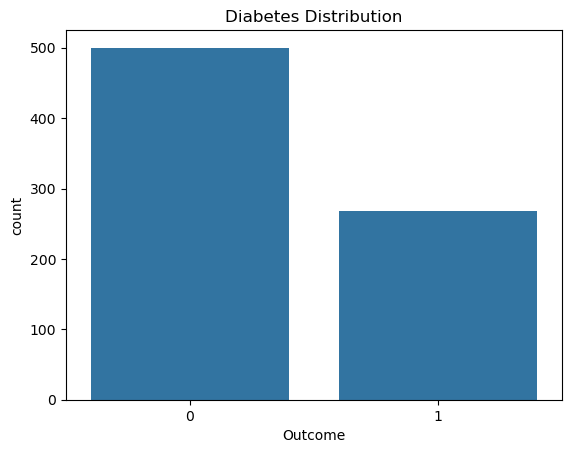

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="Outcome", data=df)
plt.title("Diabetes Distribution")
plt.show()

##A countplot bar graph was then created to visualise the distribution of the data.
This process helped me to visually understand my data and to ensure that it was suitable for training and evaluating the machine learning model

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

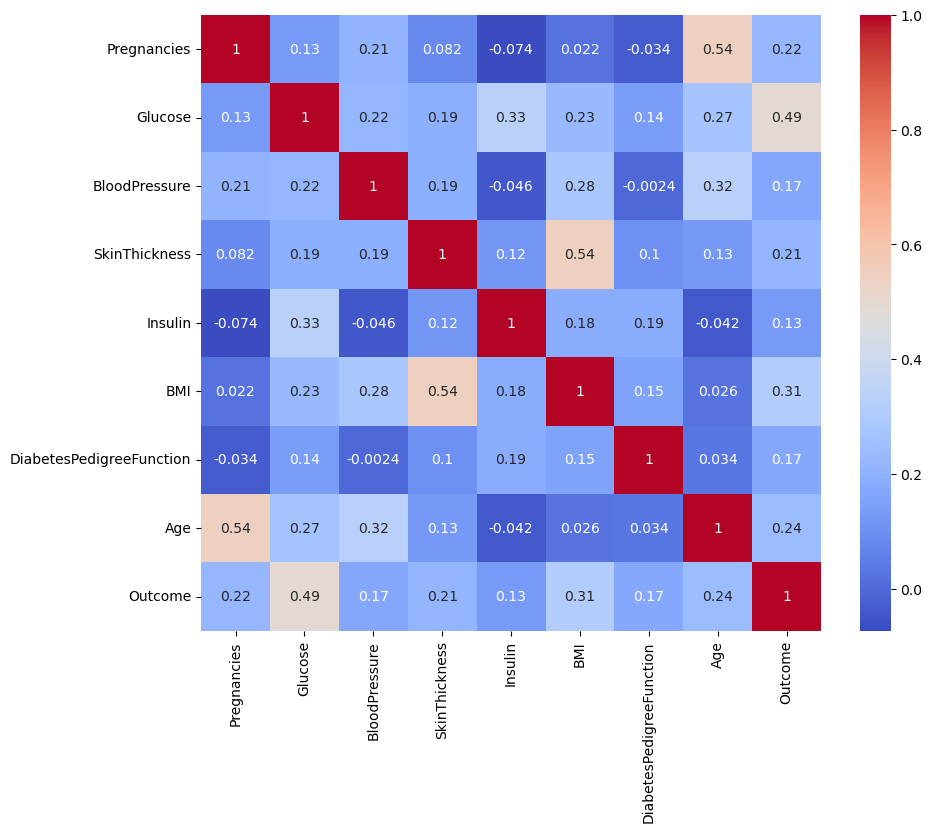

In [30]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

I used a correlation heatmap to understand the relationship between all the medical variables inthe dataset. The analysis showed that glucose had the strongest relationship with diabetes, followed by BMI. This confirmed that these variables are important predictors for our machine learning model.

In [31]:
X = df.drop("Outcome", axis=1)
Y = df["Outcome"]

In [ ]:
The dataset was divided into two parts before training the model:

* X - Which is the predictor variable containing all the medical measurements from our dataset
* Y - Which is the outcome column whereby:
 > 0 = Non diabetic patients
 > 1 = Diabetic patients

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2,random_state=42)

In [33]:
X = df.drop("Outcome", axis=1)

The dataset was divided into training and testing datasets using the train_test_split() function.

Eighty percent (80%) of the data was used to train the machine learning model, while the remaining twenty percent (20%) was reserved for testing its performance.

The random_state value of 42 was used so that the same data split could be reproduced whenever the project is run. This improves the consistency and reliability of the results.

In [34]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


The shape of training and testing was displaed to check if the data has divided correctly to prepare for evaluation 

The results showed:
• X_train contained 614 patient records with 8 predictor variables.
• X_test contained 154 patient records with the same 8 predictor variables.
• y_train contained the diabetes outcomes for the training data.
• y_test contained the diabetes outcomes for the testing data.


In [35]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


A Logistic Regression model was selected because this project involves predicting one of two possible outcomes: diabetic or non-diabetic patient

The model was trained using the training dataset so that it could learn the relationship between the medical measurements and the diabetes outcome as a result the parameter max_iter=1000 used to allow algorithm sufficient iterations to run and produce an accurate model.

In [36]:
y_pred = model.predict(X_test)

In [37]:
print(y_test)

668    0
324    0
624    0
690    0
473    0
      ..
355    1
534    0
344    0
296    1
462    0
Name: Outcome, Length: 154, dtype: int64


##The actual diabetes outcomes from the testing dataset were displayed.

The values represent the correct diagnosis for each patient and are used as a reference to evaluate the models predictions

## Displaying the Predicted Outcomes

The trained Logistic Regression model generated predictions for each patient in the testing dataset.

The predicted values were stored in the variable y_pred.

These predictions were compared with the actual outcomes (y_test) to determine the performance of the machine learning model.
Cell 39

In [40]:
print(y_pred)

[0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 1 0 0 1 0 1 1 0 0 0 0 1 1 1 1 1 1 1
 0 0 1 0 1 1 0 0 1 1 0 0 1 0 1 1 0 0 0 1 0 0 1 1 0 0 0 0 1 0 1 0 1 1 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 0 0 1 0 1 0 1 1 1 0 0 1 0 1 0
 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0]


## Displaying the Predicted Outcomes

The trained Logistic Regression model generated predictions for each patient in the testing dataset.

The predicted values were stored in the variable y_pred.

These predictions were compared with the actual outcomes (y_test) to determine the performance of the machine learning model.

In [38]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.7662337662337663


###Evaluating the accuracy of our model

This Function  was displayed to evaluate the perfomance of our model and to measure its accuracy when we compare the proportion of its predictions to the actual outcome.

It gave us the reading of 76.66% which shows that our model correctly predicted the presence of diabetes in patients 